In [9]:
import os
import shutil
from pathlib import Path

import pyvista as pv
import ogstools as ot
from ogstools.variables import Variable as ov

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meshing import create_scylindre_mesh,create_rectangle_frac_mesh_v2
from functions_s import pd_lsrf_nb,step_rate_r,save_combined_mesh

# Path

In [10]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

# Line-source 

## example preparation

In [11]:
cwd=Path.cwd()
newpath=cwd/"STIMTEC_example"
TESTSR= 'BH10_20180718_40.6'
dataex_f=pd.read_csv(newpath/"BH10_20180718_40.6_SR.csv",sep=",",header=0)
protocol=pd.read_csv(newpath/"protocol_SR.csv", sep=",",header=0)

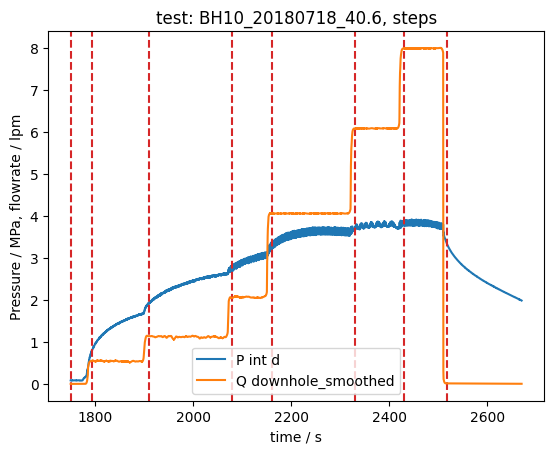

In [12]:
#isolating Step-rate and preparing curve

fig8, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa, flowrate / lpm")
plt.title(f"test: {TESTSR}, steps")

ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d")
for i in range (len(protocol)):
     ax.axvline(x=dataex_f.loc[protocol.iloc[i,0],'Zeit [s]'],ls="--",color="tab:red")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_downhole [lpm]_s'],label="Q downhole_smoothed")

plt.legend()
plt.show()
#fig8.savefig(f"{TESTSR}_marks.pdf",format='pdf')

## Line-source analytical

In [13]:
#data 
#average parameters from PPT
Dqp= 6.21e-1 #m**2/s
Tqp= 9.52E-07 #m**2/s
Sqp=1.53E-06  #-
re=8.5       # 8.63 m in reference
h=0.7         # m taken as interval length

c_t=Sqp/(1000*9.8*1.7*0.03)  # Pa-1
c_t=float(f"{c_t:.2e}")
kcal=(Tqp*1e-3)/(1000*9.8*1.7) #m**2
kcal=float(f"{kcal:.2e}")
print(f'Estimated total compressibility (Pa-1): {c_t},\nEstimated permeability (m^2): {kcal}')

ddict={"p_i":86316.0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":c_t ,
       "r_w":0.038,
       'h': h
      }

delta_t=dataex_f['Zeit [s]'].values
tp=protocol['T_s [s]'].values
q_array=protocol['qs [m**3/s]'].values

rinv=np.sqrt(kcal*(tp[-1]-tp[0])/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n"Unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Estimated total compressibility (Pa-1): 3.06e-09,
Estimated permeability (m^2): 5.71e-14
Investigation radius (m):  21.85 
"Unperturbed" threshold (m):  87.41


k:5.14e-14 m^2 
 r:[ 0.038  0.166  0.729  3.196 14.   ] m


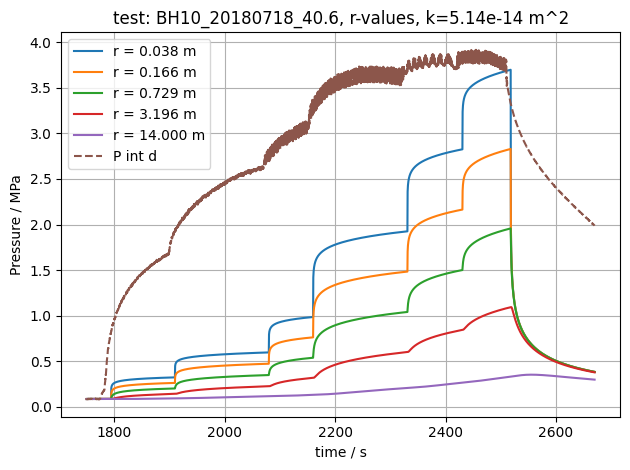

In [14]:
#evaluating best references k and re with varying r to re
rw=ddict['r_w']

r_val3=np.geomspace(ddict['r_w'],14,5).round(3) 

k_val3=5.14e-14 #np.geomspace(1e-14,1e-13,5) #5.5e-14#k_val2

print(f'k:{k_val3} m^2 {'\n'} r:{r_val3} m')

pwsr3= step_rate_r(pd_lsrf_nb, delta_t, tp, q_array, ddict, k_val3, r_val3)

line_labels13 = [f"r = {val:>5.3f} m" for val in r_val3]
# line_labels13 = [f"k = {val:>5.2e} m" for val in k_val3]

fig13, ax=plt.subplots()

ax.plot(delta_t, pwsr3/1e6, label=line_labels13)
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: {TESTSR}, r-values, k={k_val3} m^2")

plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
#fig13.savefig(f"lsrfa_fb_2D_{TESTSR}.pdf",format='pdf') #report figure

# Fracture version

## Meshing

In [15]:
MSH_FILE = MESH_DIR / "symmetric_cylinder_2D.msh"

r_well=0.038
thickness=ddict['h']  
mesh_size=thickness/4


create_rectangle_frac_mesh_v2(
    MSH_FILE,
    radius= 100,
    height= thickness,
    mesh_size= mesh_size,
    center_z=-40.6,
    r_well= r_well,      
    length=8.0
) 

meshes = ot.meshes_from_gmsh(MSH_FILE, log=False)
for name, mesh in meshes.items():
    vtu_path = MESH_DIR / f"rectangle_{name}.vtu"
    pv.save_meshio(vtu_path, mesh)
    print(f"Saved {vtu_path}")

combined_vtu = MESH_DIR / "combined_fracture_mesh.vtu"
save_combined_mesh(MSH_FILE, combined_vtu)

AttributeError: module 'ogstools' has no attribute 'meshes_from_gmsh'

In [ ]:
import ogstools.meshlib as meshlib
print(meshlib.__file__) # This will tell us EXACTLY where it is loading from

ModuleNotFoundError: No module named 'ogstools.meshlib'

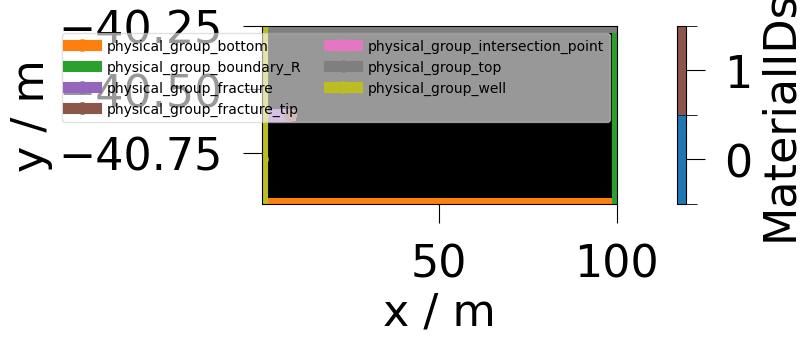

In [ ]:
mesh_to_plot=ot.Mesh.read(combined_vtu)

fig14= mesh_to_plot.plot_contourf(
    "MaterialIDs",
    figsize=(8, 6),
    dpi=100,
    cmap="tab20",
    alpha=0.3,
    linewidth=0,
)
ax = fig14.axes[0]
for i, (name, mesh) in enumerate(sorted(meshes.items())):
    if mesh.area:  
        continue
    
    ls, marker = ("-", "") if "boundary" in name else ("-", "o")
    
    ot.plot.line(
        mesh,
        ax=ax,
        color=f"C{i}",
        lw=2,
        ls=ls,
        marker=marker,
        markersize=8,
        label=name,
    )

#ax.set_aspect("equal")
ax.legend(ncol=2, loc='upper right',framealpha=0.6)
plt.show()

## Running OGS base

In [ ]:
!ogs ./BH10_20180718_40.6_v2.prj -m ./_out/mesh -o ./_out/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-04-08 17:52:25+0200.
info: Eigen use 16 threads
info: Reading project file BH10_20180718_40.6_v3.prj.
info: readRasters ...
info: readRasters done
info: GroupBasedParameter: fracture_thickness
info: ConstantParameter: p0
info: ConstantParameter: p_tb
info: ConstantParameter: pi_bd
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 1750.009. Step size: 0.
info: [time] Output of timestep 0 took 0.0273504 s.
info: Time step #0 took 0.0317083 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-04-08 17:52:25+0200.
info: Solve processes.
info: Time step #1 started. Time: 1750.1089999999999. Step size: 0.10000000000000001.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.0172392 s.
info: [time] Applying Dirichlet BCs took 0.0004772 s.
info: -------------------------------------

## Results and visualisation base


In [ ]:
pvd_path = Path("_out/BH10_20180718_40.6.pvd")
ms1 = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="MPa")

In [ ]:
y=-40.6
r_st=0.038 #equating the rgeo analytical
r_en=14

coords=np.array(np.geomspace([r_st,y,1e-18],[r_en,y,1e-18],5).round(3)) #extracting along x linearly
ms_probes1 = ms1.extract_probe(ms1,points=coords)

labels = [f"OGS: r={pt[0]:>5.3f}, y={y}" for pt in coords]
timeogs1=ms_probes1.timevalues
pwsr3p= step_rate_r(pd_lsrf_nb, timeogs1, tp, q_array, ddict, k_val3, r_val3)

diff = pwsr3p - ms_probes1['pressure']

100%|████████████████████████████████████████████████████████████████████████████████| 103/103 [00:02<00:00, 46.60it/s]


### Analytical and Numerical OGS comparison

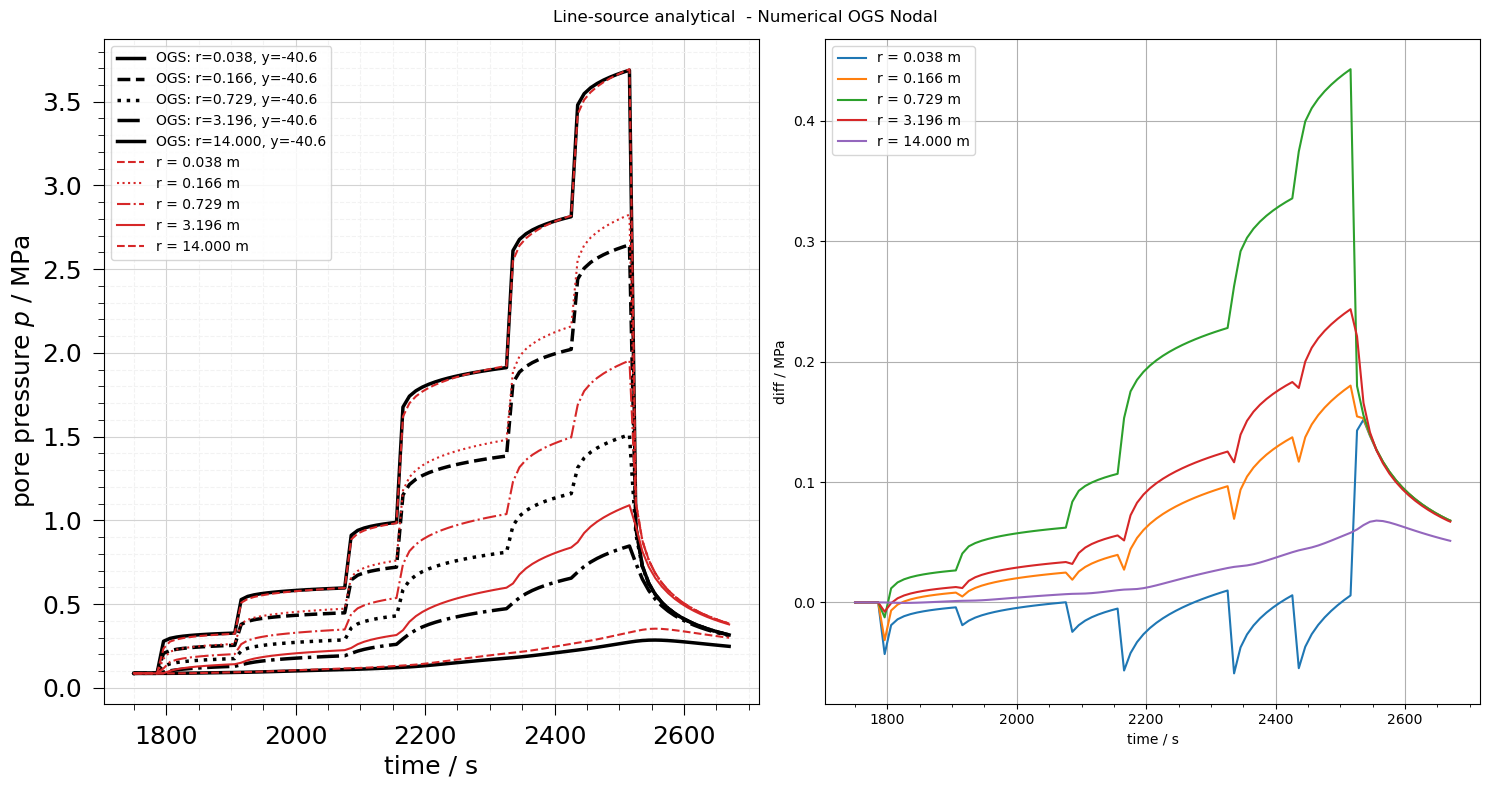

In [ ]:
fig15, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,8], sharex=True)
ot.plot.line(ms_probes1,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(timeogs1, pwsr3p/1e6,color='tab:red', label=line_labels13) 
axs[1].plot(timeogs1, diff/1e6, label=line_labels13)

fig15.suptitle("Line-source analytical  - Numerical OGS Nodal") 
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / MPa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

plt.show()

## Running OGS example

In [ ]:
!ogs ./BH10_20180718_40.6_v3.prj -m ./_out/mesh -o ./_out/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-04-08 22:45:18+0200.
info: Eigen use 16 threads
info: Reading project file BH10_20180718_40.6_v3.prj.
info: readRasters ...
info: readRasters done
info: GroupBasedParameter: fracture_thickness
info: ConstantParameter: p0
info: ConstantParameter: p_tb
info: ConstantParameter: pi_bd
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 1750.009. Step size: 0.
info: [time] Output of timestep 0 took 0.0453747 s.
info: Time step #0 took 0.0519554 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-04-08 22:45:18+0200.
info: Solve processes.
info: Time step #1 started. Time: 1750.1089999999999. Step size: 0.10000000000000001.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.0231064 s.
info: [time] Applying Dirichlet BCs took 0.0006842 s.
info: -------------------------------------

## Results and visualisation example

In [ ]:
pvd_path = Path("_out/BH10_20180718_40.6.pvd")
ms2 = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="MPa")

In [ ]:
y=-40.6
r_st=0.038 #equating the rgeo analytical

coords=np.array([r_st,y,1e-18]).round(3) #extracting along x linearly
ms_probes2 = ms2.extract_probe(ms2,points=coords)

labels2 = f"OGS (m): r={coords[0]:>5.3f}, y={y}"

exp_time = dataex_f['Zeit [s]'].values
exp_pres = dataex_f['Pint_downhole [MPa]'].values
timeogs2 = ms_probes2.timevalues  

ma_indices = [np.abs(exp_time - t).argmin() for t in timeogs2]
exp_at_OGS = exp_pres[ma_indices]
residual_pressure = exp_at_OGS.flatten() - ms_probes2['pressure'].flatten()

100%|████████████████████████████████████████████████████████████████████████████████| 103/103 [00:03<00:00, 31.09it/s]


### Analytical and Numerical OGS comparison: example

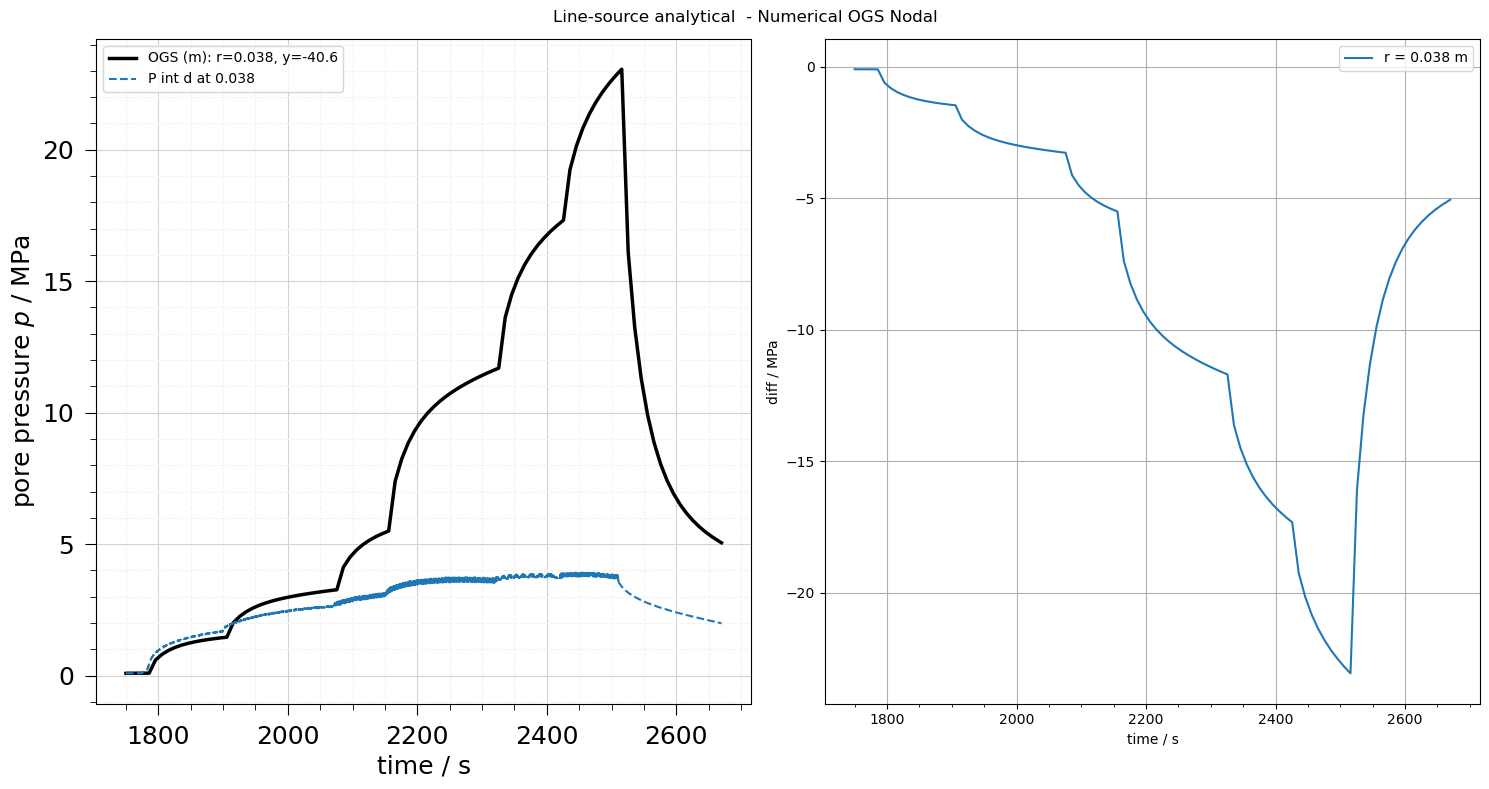

In [ ]:
fig16, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,8], sharex=True)
ot.plot.line(ms_probes2,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels2)
axs[0].plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label=f"P int d at {rw}")
axs[1].plot(timeogs2, residual_pressure/1e6, label=line_labels13[0])


fig16.suptitle("Line-source analytical  - Numerical OGS Nodal") 
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / MPa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

plt.show()